In [1]:
import numpy as np
import matplotlib.pyplot as plt
from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.Propeller import Propeller
from FastBEMT.DataLoader import load_propeller_dict
from PropGen.BladeDictGenerator import generate_blade_dict
import pickle
import scienceplots
plt.style.use(['science','no-latex'])

# blade_dict = load_propeller_dict('run_001/Pareto1')

params = LowFidelityParameters(
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    n_blades=2,
    p_ref=2e-5,
    revolutions=5,
    num_obs_times_per_rev=100,
    device='cuda',
)

In [2]:
blade_dict = load_propeller_dict('Pareto1')

In [3]:
propeller = Propeller(
    geometry=blade_dict,
    params=params,
)
v_inf = 0
propeller.run_bemt(v_inf=v_inf)

In [4]:
propeller.compute_total_forces()

(np.float64(8.005912658162792),
 np.float64(0.11721910643748354),
 np.float64(0.11535762691184542),
 np.float64(0.041781114811313004))

In [10]:
from FastBEMT.Stress import BladeStressCalculator

stress_calc = BladeStressCalculator(propeller=propeller)
sigma_c, sigma_b = stress_calc.blade_stress_report(material_rho=2700, show = False)

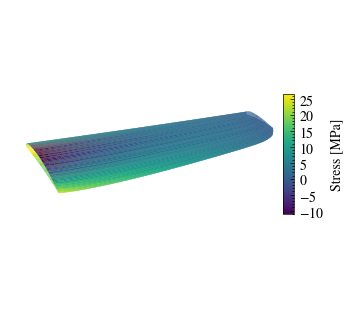

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib as mpl
cmap = mpl.colormaps['viridis']

geom = propeller.geometry
r = np.asarray(geom['r'])
chord = np.asarray(geom['chord'])
twist = np.radians(np.asarray(geom['twist']))
airfoils = geom['airfoil']

sigma_c = np.asarray(sigma_c)
sigma_b = np.asarray(sigma_b)

if sigma_b.ndim == 1:
    sigma_total = sigma_c + sigma_b
    sigma_total = sigma_total[:, np.newaxis]
else:
    sigma_total = sigma_b + sigma_c[:, np.newaxis]

n_sections = len(r)
n_points = airfoils[0].shape[0]

X = np.zeros((n_sections, n_points))
Y = np.zeros((n_sections, n_points))
Z = np.zeros((n_sections, n_points))
S = np.zeros((n_sections, n_points))

for i in range(n_sections):
    coords = np.asarray(airfoils[i])
    x_local = coords[:, 0] * chord[i]
    z_local = coords[:, 1] * chord[i]

    if hasattr(propeller, 'com_shift_forward') and hasattr(propeller, 'com_shift_up'):
        x_local = x_local + propeller.com_shift_forward[i] * chord[i]
        z_local = z_local + propeller.com_shift_up[i] * chord[i]

    cos_t = np.cos(twist[i])
    sin_t = np.sin(twist[i])
    x_rot = x_local * cos_t + z_local * sin_t
    z_rot = -x_local * sin_t + z_local * cos_t

    X[i, :] = x_rot
    Y[i, :] = r[i]
    Z[i, :] = z_rot

    if sigma_total.ndim == 2 and sigma_total.shape[1] == n_points:
        S[i, :] = sigma_total[i, :]
    else:
        S[i, :] = sigma_total[i]

r_fine = np.linspace(r.min(), r.max(), 50)
X_fine = np.zeros((len(r_fine), n_points))
Z_fine = np.zeros((len(r_fine), n_points))
S_fine = np.zeros((len(r_fine), n_points))

for j in range(n_points):
    X_fine[:, j] = np.interp(r_fine, r, X[:, j])
    Z_fine[:, j] = np.interp(r_fine, r, Z[:, j])
    S_fine[:, j] = np.interp(r_fine, r, S[:, j])

Y_fine = np.repeat(r_fine[:, np.newaxis], n_points, axis=1)
S_mpa = S_fine / 1e6

fig = plt.figure(figsize=(4.5, 3))
ax = fig.add_subplot(111, projection='3d')

norm = Normalize(vmin=np.nanmin(S_mpa), vmax=np.nanmax(S_mpa))
ax.plot_surface(
    X_fine,
    Y_fine,
    Z_fine,
    facecolors=cmap(norm(S_mpa)),
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=True,
    shade=False,
    edgecolor='none',
    vmin=-10,
    vmax=20,
)

z_min = np.nanmin(Z_fine)
z_max = np.nanmax(Z_fine)
pad = 0.01 * (z_max - z_min)
ax.set_zlim(z_min - pad, z_max + pad)

ax.set_axis_off()
ax.set_box_aspect((np.ptp(X_fine), np.ptp(Y_fine), np.ptp(Z_fine)))

vmin = np.floor(S_mpa.min() / 10) * 10
vmax = np.ceil(S_mpa.max() / 10) * 10

mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array(S_mpa)
cbar = fig.colorbar(mappable, ax=ax, shrink=0.4, pad=-0.05, aspect=10)
cbar.set_label('Stress [MPa]')
cbar.set_ticks(ticks=[-10, -5, 0, 5, 10, 15, 20, 25])
ax.view_init(elev=15, azim=-30)
plt.tight_layout(pad=0)
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0, hspace=0)
plt.gca().set_aspect('auto', adjustable='box')
plt.savefig('../Figures/fig1.pdf', bbox_inches='tight', dpi=200)
plt.savefig('../Figures/pca_opt.svg', bbox_inches='tight', dpi=200)
plt.show()